In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [2]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [3]:
df = sns.load_dataset("titanic")

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
df.sample(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
163,0,3,male,17.0,0,0,8.6625,S,Third,man,True,NaN,Southampton,no,True
418,0,2,male,30.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
822,0,1,male,38.0,0,0,0.0000,S,First,man,True,NaN,Southampton,no,True
85,1,3,female,33.0,3,0,15.8500,S,Third,woman,False,NaN,Southampton,yes,False
761,0,3,male,41.0,0,0,7.1250,S,Third,man,True,NaN,Southampton,no,True


In [6]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [8]:
df = df[['survived', 'pclass', 'sex', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'adult_male']]

In [9]:
df.sample(4)

,survived,pclass,sex,sibsp,parch,fare,embarked,class,adult_male
885,0,3,female,0,5,29.1250,Q,Third,False
671,0,1,male,1,0,52.0000,S,First,True
874,1,2,female,1,0,24.0000,C,Second,False
197,0,3,male,0,1,8.4042,S,Third,True


In [10]:
df = df.dropna()

In [11]:
df = df.drop_duplicates()

In [12]:
df.shape

(502, 9)

In [13]:
X_train, x_test, Y_train, y_test = train_test_split(df.iloc[:,1:], df.iloc[:,0], train_size=0.8, random_state=42)

In [14]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [15]:
colt = ColumnTransformer(transformers=[
    ("scaling", StandardScaler(), ['fare']),
    ('oridnal encoding', OrdinalEncoder(), ['embarked', 'class']),
    ('ohe', OneHotEncoder(), ['sex', 'adult_male'])
], remainder='passthrough')

In [26]:
from sklearn.pipeline import Pipeline
pipe_log = Pipeline([
    ('colt', colt),
    ('ling', LogisticRegression())
    # ('svc', SVC()), 
    # ('gausian', GaussianNB())
])

pipe_svc = Pipeline([
    ('colt', colt),
    ('svc', SVC(probability=True)) 
    # ('gausian', GaussianNB())
])

pipe_gausian = Pipeline([
    ('colt', colt),
    ('gausian', GaussianNB())
])

In [27]:
pipe_log.fit(X_train, Y_train)
pipe_svc.fit(X_train, Y_train)
pipe_gausian.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('colt', ...), ('gausian', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaling', ...), ('oridnal encoding', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the di

## form here the ROC and AUP will start

In [28]:
from  sklearn.metrics import roc_curve, roc_auc_score

In [35]:
log_pred = pipe_log.predict_proba(x_test)[:,1]
svc_pred = pipe_svc.predict_proba(x_test)[:,1]
gau_pred = pipe_gausian.predict_proba(x_test)[:,1]

In [36]:
lfpr, ltpr, ltreshold = roc_curve(y_test, log_pred)
sfpr, stpr, streshold = roc_curve(y_test, svc_pred)
gfpr, gtpr, gtreshold = roc_curve(y_test, gau_pred)

<Axes: >

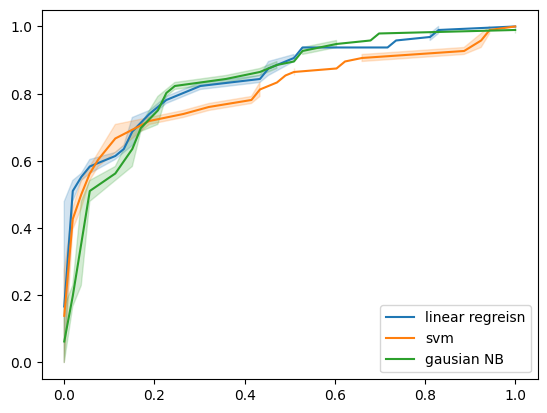

In [42]:
sns.lineplot(x = lfpr, y = ltpr, label = 'linear regreisn')
sns.lineplot(x = sfpr, y = stpr, label = 'svm')
sns.lineplot(x = gfpr, y = gtpr, label = 'gausian NB')

In [43]:
# Here we are finding a best threshold
lin = ltreshold[np.argmax(ltpr - lfpr)]
svc = streshold[np.argmax(stpr - sfpr)]
gnb = gtreshold[np.argmax(gtpr - gfpr)]

In [44]:
lin, svc, gnb

(np.float64(0.5057714430065523),
 np.float64(0.43926136761031354),
 np.float64(0.07716928371087729))

In [45]:
# area under the curve

In [47]:
larea = roc_auc_score(y_test, log_pred)
sarea = roc_auc_score(y_test, svc_pred)
garea = roc_auc_score(y_test, gau_pred)

In [48]:
larea, sarea, garea

(0.854559748427673, 0.8140723270440251, 0.8388364779874214)